In [ ]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker   as ticker
from pathlib import Path
from scipy.stats import pearsonr, ttest_1samp, ttest_rel
from statsmodels.stats.multitest import multipletests
from collections import Counter


In [ ]:

# PATHS

fmri_dir = Path(
    "/Users/lunameidoering/Desktop/CODE/fMRI/RSA/cat_avg_RDMs_13subs/"
)
model_dirs = {
    "dvdmodel": Path(
        "/Users/lunameidoering/Desktop/CODE/Models/dvd_imagenet_cv/results/"
    ),
    "baseline": Path(
        "/Users/lunameidoering/Desktop/CODE/Models/baseline_imagenet_cv/results/"
    ),
}
master_output_dir = Path(
    "/Users/lunameidoering/Desktop/CODE/Models/out/rdm_13subs/"
)
plot_output_dir = master_output_dir / "plots"
master_output_dir.mkdir(parents=True, exist_ok=True)
plot_output_dir.mkdir(parents=True, exist_ok=True)


In [ ]:
# CONSTANTS
SUBJECTS  = ["sub01","sub02","sub03","sub04","sub05","sub06","sub07",
             "sub08","sub09","sub10","sub11","sub12","sub14"]
MODELS    = ["baseline", "dvdmodel"]

# Ordered category names used as keys throughout
FMRI_COLS = ["Bodies", "Hands", "Tools", "Manip", "Non-manip"]
N_CATS    = len(FMRI_COLS)
N_STIMULI = 200

RDM_MODEL_FILE = "RDM_features_singleStim.csv"

# Mapping from internal name → label used in fMRI CSV row/col headers
FMRI_LABEL_MAP    = {"Bodies": "Bodies", "Hands": "Hands", "Tools": "Tools",
                      "Manip": "Manip", "Non-manip": "Non-manip"}
FMRI_LABEL_TO_KEY = {v: k for k, v in FMRI_LABEL_MAP.items()}

# 0-indexed RAW STIMULUS positions for each category (used only to compute
# category sizes; the model RDM CSV rows/cols are already in contiguous
# category-block order: bodies 0-24, hands 25-49, tools 50-99, mani 100-149,
# nman 150-199 — NOT in the scattered raw-stimulus order below).
IDX_MAPPING = {
    "bodies": list(range(0,  12)) + list(range(100, 113)),  # 25 stimuli
    "hands":  list(range(12, 25)) + list(range(113, 125)),  # 25 stimuli
    "tools":  list(range(25, 50)) + list(range(125, 150)),  # 50 stimuli
    "mani":   list(range(50, 75)) + list(range(150, 175)),  # 50 stimuli
    "nman":   list(range(75,100)) + list(range(175, 200)),  # 50 stimuli
}
CAT_SIZES = {cat: len(idxs) for cat, idxs in IDX_MAPPING.items()}
# bodies=25, hands=25, tools=50, mani=50, nman=50

# Maps FMRI_COLS entry (e.g. "Bodies") → IDX_MAPPING key (e.g. "bodies")
FMRI_TO_IDX_KEY = {
    "Bodies":    "bodies",
    "Hands":     "hands",
    "Tools":     "tools",
    "Manip":     "mani",
    "Non-manip": "nman",
}

#   positions 0-24   → Bodies  (25 stimuli)
#   positions 25-49  → Hands   (25 stimuli)
#   positions 50-99  → Tools   (50 stimuli)
#   positions 100-149 → Manip  (50 stimuli)
#   positions 150-199 → Non-manip (50 stimuli)


cat_of_position = np.array(
    [cat_i
     for cat_i, cat_name in enumerate(FMRI_COLS)
     for _ in IDX_MAPPING[FMRI_TO_IDX_KEY[cat_name]]],
    dtype=int,
)
assert len(cat_of_position) == N_STIMULI

cat_sizes_list = [CAT_SIZES[FMRI_TO_IDX_KEY[c]] for c in FMRI_COLS]
cum_sizes      = np.cumsum([0] + cat_sizes_list)   # [0,25,50,100,150,200]
cat_boundaries = cum_sizes[1:-1] - 0.5             # [24.5, 49.5, 99.5, 149.5]
cat_centers    = [(cum_sizes[i] + cum_sizes[i+1]) / 2
                  for i in range(N_CATS)]           # midpoints of each block

CAT_LABELS = {"bodies": "Body", "hands": "Hand", "tools": "Tool",
              "mani": "Manip", "nman": "Non-manip"}

CONDITION_ORDER = ["natural", "gatys", "texform"]
ROI_ORDER       = ["body", "hand", "tool"]
MODELS_ORDERED  = ["dvdmodel", "baseline"]   # display order in bar plot

MODEL_LABELS = {"baseline": "Baseline", "dvdmodel": "DVD Model"}
ROI_LABELS   = {"body": "LOTC Body Left", "hand": "LOTC Hand Left",
                "tool": "LOTC Tool Left"}
COND_LABELS  = {"natural": "Natural", "gatys": "Gatys", "texform": "Texform"}
COLORS       = {"baseline": "#C0392B", "dvdmodel": "#1A6B8A"}

PATTERNS_MODEL = {
    "dvdmodel": re.compile(r"encoding_model_balanced_(.+)_LOTC_(.+)_left\.mat"),
    "baseline":  re.compile(r"encoding_model_baseline_(.+)_LOTC_(.+)_left\.mat"),
}

# Upper-triangle indices for a 5×5 matrix, diagonal excluded (10 values)
UTRI_IDX = np.triu_indices(N_CATS, k=1)


In [ ]:

def upper_tri(mat):
    """Upper triangle without diagonal, row-major order (works for any square mat)."""
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]


def upper_tri_off_diag_5x5(mat):
    """10 off-diagonal upper-triangle values of a 5×5 matrix."""
    return mat[UTRI_IDX]


def load_fmri_rdm(csv_path):
    """Load a 5×5 fMRI RDM CSV → (5×5) ndarray ordered by FMRI_COLS."""
    df = pd.read_csv(csv_path, index_col=0)
    df.index   = df.index.str.strip()
    df.columns = df.columns.str.strip()
    df.index   = [FMRI_LABEL_TO_KEY.get(l, l) for l in df.index]
    df.columns = [FMRI_LABEL_TO_KEY.get(l, l) for l in df.columns]
    missing = [c for c in FMRI_COLS if c not in df.index]
    if missing:
        raise ValueError(f"Missing categories {missing} in {csv_path.name}. "
                         f"Found: {list(df.index)}")
    return df.loc[FMRI_COLS, FMRI_COLS].to_numpy(dtype=float)


def load_model_rdm(csv_path):
    """Load a 200×200 model RDM CSV → (200×200) ndarray."""
    df  = pd.read_csv(csv_path, index_col=0)
    mat = df.to_numpy(dtype=float)
    if mat.shape != (N_STIMULI, N_STIMULI):
        raise ValueError(f"Expected {N_STIMULI}×{N_STIMULI}, got {mat.shape}")
    return mat


def collapse_model_rdm_to_5x5(mat200):
    """
    Average a 200×200 model RDM (rows/cols in CONTIGUOUS category-block order)
    into a 5×5 category RDM.

    Uses cat_of_position to identify which positions belong to each category,
    matching the original script's rdm_to_category_5x5 approach exactly.

    """
    rdm5 = np.full((N_CATS, N_CATS), np.nan)
    for i in range(N_CATS):
        idx_i = np.where(cat_of_position == i)[0]
        for j in range(N_CATS):
            idx_j = np.where(cat_of_position == j)[0]
            block = mat200[np.ix_(idx_i, idx_j)]
            if i == j:
                tri  = np.triu_indices_from(block, k=1)
                vals = block[tri]
            else:
                vals = block.ravel()
            rdm5[i, j] = np.nanmean(vals)
    return rdm5


def expand_fmri_rdm(rdm_5x5):
    """
    Cast a 5×5 fMRI RDM to 200×200 in the same contiguous-block order
    as the model RDM CSV (needed for 200×200 upper-triangle correlations).
    """
    return rdm_5x5[np.ix_(cat_of_position, cat_of_position)]


def get_spearman(v1, v2):
    """Spearman ρ between two vectors; returns 0 on constant input."""
    v1, v2 = np.array(v1, dtype=float), np.array(v2, dtype=float)
    if np.var(v1) == 0 or np.var(v2) == 0:
        return 0.0
    r, _ = pearsonr(v1, v2)
    return float(r) if not np.isnan(r) else 0.0


def sig_stars(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."


## Load fMRI RDMs

In [ ]:

fmri_rdm_dict = {}
fmri_pattern  = re.compile(
    r"^(sub\d+)_(original|gatys|texform)_(body|hand|tool)_fmri_RDM\.csv$"
)
for fname in sorted(os.listdir(fmri_dir)):
    m = fmri_pattern.match(fname)
    if not m:
        continue
    sub, condition, roi = m.groups()
    if condition == "original":
        condition = "natural"
    try:
        mat = load_fmri_rdm(fmri_dir / fname)
        fmri_rdm_dict[(sub, condition, roi)] = mat
    except Exception as e:
        warnings.warn(f"Skipping {fname}: {e}")

print(f"Loaded {len(fmri_rdm_dict)} fMRI 5×5 RDMs.")
counter = Counter((cond, roi) for _, cond, roi in fmri_rdm_dict.keys())
for (cond, roi), count in sorted(counter.items()):
    print(f"  Condition: {cond}, ROI: {roi}, Subjects: {count}")

# Pre-expand all fMRI RDMs to 200×200 for use in the full-resolution stats
fmri_rdm_expanded = {
    key: expand_fmri_rdm(mat)
    for key, mat in fmri_rdm_dict.items()
}
print(f"Expanded {len(fmri_rdm_expanded)} fMRI RDMs to {N_STIMULI}×{N_STIMULI}.")



Loaded 114 fMRI 5×5 RDMs.
  Condition: gatys, ROI: body, Subjects: 13
  Condition: gatys, ROI: hand, Subjects: 13
  Condition: gatys, ROI: tool, Subjects: 12
  Condition: natural, ROI: body, Subjects: 13
  Condition: natural, ROI: hand, Subjects: 13
  Condition: natural, ROI: tool, Subjects: 12
  Condition: texform, ROI: body, Subjects: 13
  Condition: texform, ROI: hand, Subjects: 13
  Condition: texform, ROI: tool, Subjects: 12
Expanded 114 fMRI RDMs to 200×200.
Loaded 18 raw 200×200 model RDMs.
Collapsed to 18 category-level 5×5 model RDMs.

Master DataFrame: 132 rows
medium    condition  roi 
baseline  gatys      body    1
                     hand    1
                     tool    1
          natural    body    1
                     hand    1
                            ..
sub14     natural    hand    1
                     tool    1
          texform    body    1
                     hand    1
                     tool    1
Name: count, Length: 132, dtype: int64
Saved per_subjec

/var/folders/xb/lzcnd2h15s521bd0p0c7mc6r0000gn/T/ipykernel_38931/2631407371.py:118: UserWarning: No fMRI RDM for ('sub12', 'natural', 'tool')
  warnings.warn(f"No fMRI RDM for {key_fmri}")
/var/folders/xb/lzcnd2h15s521bd0p0c7mc6r0000gn/T/ipykernel_38931/2631407371.py:118: UserWarning: No fMRI RDM for ('sub12', 'gatys', 'tool')
  warnings.warn(f"No fMRI RDM for {key_fmri}")
/var/folders/xb/lzcnd2h15s521bd0p0c7mc6r0000gn/T/ipykernel_38931/2631407371.py:118: UserWarning: No fMRI RDM for ('sub12', 'texform', 'tool')
  warnings.warn(f"No fMRI RDM for {key_fmri}")


## LOAD MODEL RDMs

In [ ]:

model_rdm_dict  = {}
model_rdm5_dict = {}

for model_name, base_dir in model_dirs.items():
    if not base_dir.exists():
        warnings.warn(f"Directory not found: {base_dir}")
        continue
    pattern = PATTERNS_MODEL[model_name]
    for folder in sorted(os.listdir(base_dir)):
        folder_path = base_dir / folder
        if not folder_path.is_dir():
            continue
        match = pattern.match(folder)
        if not match:
            continue
        condition, roi = match.groups()
        csv_path = folder_path / RDM_MODEL_FILE
        if not csv_path.exists():
            warnings.warn(f"Missing: {csv_path}")
            continue
        try:
            mat200 = load_model_rdm(csv_path)
            model_rdm_dict[ (model_name, condition, roi)] = mat200
            model_rdm5_dict[(model_name, condition, roi)] = collapse_model_rdm_to_5x5(mat200)
        except Exception as e:
            warnings.warn(f"Skipping {csv_path}: {e}")

print(f"Loaded {len(model_rdm_dict)} raw 200×200 model RDMs.")
print(f"Collapsed to {len(model_rdm5_dict)} category-level 5×5 model RDMs.")


# BUILD MASTER DATAFRAME


rdm_rows = []
for (sub, condition, roi), rdm_200 in fmri_rdm_expanded.items():
    rdm_rows.append({"medium": sub, "condition": condition, "roi": roi,
                     "uppertriangle": upper_tri(rdm_200)})
for (model_name, condition, roi), rdm_200 in model_rdm_dict.items():
    rdm_rows.append({"medium": model_name, "condition": condition, "roi": roi,
                     "uppertriangle": upper_tri(rdm_200)})

master_df = pd.DataFrame(rdm_rows)
master_df.to_pickle(master_output_dir / "master_uppertri_rdm.pkl")
print(f"\nMaster DataFrame: {len(master_df)} rows")
print(master_df[["medium", "condition", "roi"]].value_counts().sort_index())


def get_subject_tris(condition, roi):
    """Return (n_subjects × n_tri) array of fMRI upper-triangle vectors."""
    rows = master_df[
        (master_df.condition == condition) &
        (master_df.roi       == roi) &
        (master_df.medium.isin(SUBJECTS))
    ]
    return np.array([np.asarray(r["uppertriangle"]) for _, r in rows.iterrows()])



## CORRELATE

In [ ]:

corr_dict = {}
for model_name in MODELS:
    for condition in CONDITION_ORDER:
        for roi in ROI_ORDER:
            key_model = (model_name, condition, roi)
            if key_model not in model_rdm5_dict:
                warnings.warn(f"No model RDM for {key_model}")
                continue
            model_vec = upper_tri_off_diag_5x5(model_rdm5_dict[key_model])
            rhos = []
            for sub in SUBJECTS:
                key_fmri = (sub, condition, roi)
                if key_fmri not in fmri_rdm_dict:
                    warnings.warn(f"No fMRI RDM for {key_fmri}")
                    rhos.append(np.nan)
                    continue
                fmri_vec = upper_tri_off_diag_5x5(fmri_rdm_dict[key_fmri])
                rho, _   = pearsonr(model_vec, fmri_vec)
                rhos.append(rho)
            corr_dict[key_model] = np.array(rhos)


_export_rows = [
    {"subject": sub, "model": m, "condition": c, "roi": r, "rho": float(rho)}
    for (m, c, r), rhos in corr_dict.items()
    for sub, rho in zip(SUBJECTS, rhos)
    if not np.isnan(rho)
]
pd.DataFrame(_export_rows).to_csv(
    master_output_dir / "per_subject_rho.csv",
    index=False, sep=";", float_format="%.6g")
print(f"Saved per_subject_rho.csv  ({len(_export_rows)} rows)")




## NOISE CEILING

In [ ]:

# For each condition × ROI:
#   For each subject i, correlate their 5×5 upper-triangle with the mean of
#   all OTHER subjects' upper-triangles (LOO mean).
#   Lower NC = mean of those per-subject correlations.


noise_ceiling = {}
for condition in CONDITION_ORDER:
    for roi in ROI_ORDER:
        vecs = []
        for sub in SUBJECTS:
            key = (sub, condition, roi)
            if key in fmri_rdm_dict:
                vecs.append(upper_tri_off_diag_5x5(fmri_rdm_dict[key]))
        if len(vecs) < 2:
            warnings.warn(f"Not enough subjects for NC: {condition}, {roi}")
            noise_ceiling[(condition, roi)] = np.nan
            continue
        vecs = np.array(vecs)
        N    = len(vecs)
        loo_rhos = []
        for i in range(N):
            loo_mean = np.delete(vecs, i, axis=0).mean(axis=0)
            rho, _   = pearsonr(vecs[i], loo_mean)
            loo_rhos.append(rho)
        noise_ceiling[(condition, roi)] = float(np.mean(loo_rhos))

print("\n── Lower noise ceiling (mean LOO Spearman ρ, 5×5) ──")
for (cond, roi), val in noise_ceiling.items():
    print(f"  {cond:10s}  {roi:6s}  NC_lower = {val:.3f}")


## STATS

In [ ]:

# One-sample t-tests (H0: mean ρ = 0), Bonferroni across 18 tests
onesample_results = []
for model_name in MODELS:
    for condition in CONDITION_ORDER:
        for roi in ROI_ORDER:
            rhos  = corr_dict.get((model_name, condition, roi), np.array([]))
            valid = rhos[~np.isnan(rhos)]
            t, p  = ttest_1samp(valid, popmean=0)
            n     = len(valid)
            mean_rho = valid.mean()
            nc    = noise_ceiling.get((condition, roi), np.nan)
            onesample_results.append({
                "model": model_name, "condition": condition, "roi": roi,
                "n": n,
                "mean_rho": mean_rho,
                "sem_rho": valid.std(ddof=1) / np.sqrt(n),
                "t": t, "p_raw": p,
                "noise_ceiling": nc,
                "pct_noise_ceiling": (mean_rho / nc * 100) if not np.isnan(nc) and nc != 0 else np.nan,
            })


df_onesample = pd.DataFrame(onesample_results)
for roi in ROI_ORDER:
    mask = df_onesample.roi == roi
    df_onesample.loc[mask, "p_corr"] = np.minimum(
        df_onesample.loc[mask, "p_raw"] * 6, 1.0)

df_onesample.to_csv(
    master_output_dir / "stats_onesample.csv", index=False,
    float_format="%.3f"
)
print("\n── One-sample t-tests, Bonferroni × 6 per ROI ──")
print(df_onesample[
    ["model","condition","roi","mean_rho","sem_rho","t","p_raw","p_corr",
     "noise_ceiling","pct_noise_ceiling"]
].to_string(index=False))

# Paired t-tests (dvdmodel vs baseline), Bonferroni across 9 tests
paired_results = []
for condition in CONDITION_ORDER:
    for roi in ROI_ORDER:
        rhos_dvd  = corr_dict.get(("dvdmodel",  condition, roi),
                                   np.full(len(SUBJECTS), np.nan))
        rhos_base = corr_dict.get(("baseline", condition, roi),
                                   np.full(len(SUBJECTS), np.nan))
        mask   = ~np.isnan(rhos_dvd) & ~np.isnan(rhos_base)
        dvd_v  = rhos_dvd[mask]
        base_v = rhos_base[mask]
        n      = mask.sum()
        t, p   = ttest_rel(dvd_v, base_v)
        diff   = dvd_v - base_v
        paired_results.append({
            "condition": condition, "roi": roi, "n": n,
            "mean_diff (dvd-base)": diff.mean(),
            "sem_diff": diff.std(ddof=1) / np.sqrt(n),
            "t": t, "p_raw": p,
        })

df_paired = pd.DataFrame(paired_results)
for roi in ROI_ORDER:
    mask = df_paired.roi == roi
    df_paired.loc[mask, "p_corr"] = np.minimum(
        df_paired.loc[mask, "p_raw"] * 3, 1.0)

df_paired.to_csv(
    master_output_dir / "stats_paired.csv", index=False,
    float_format="%.3f"
)

print("\n── Paired t-tests (dvdmodel vs baseline), Bonferroni × 3 per ROI ──")
print(df_paired[
    ["condition","roi","n","mean_diff (dvd-base)","sem_diff","t","p_raw","p_corr"]
].to_string(index=False))


## PLOTTING

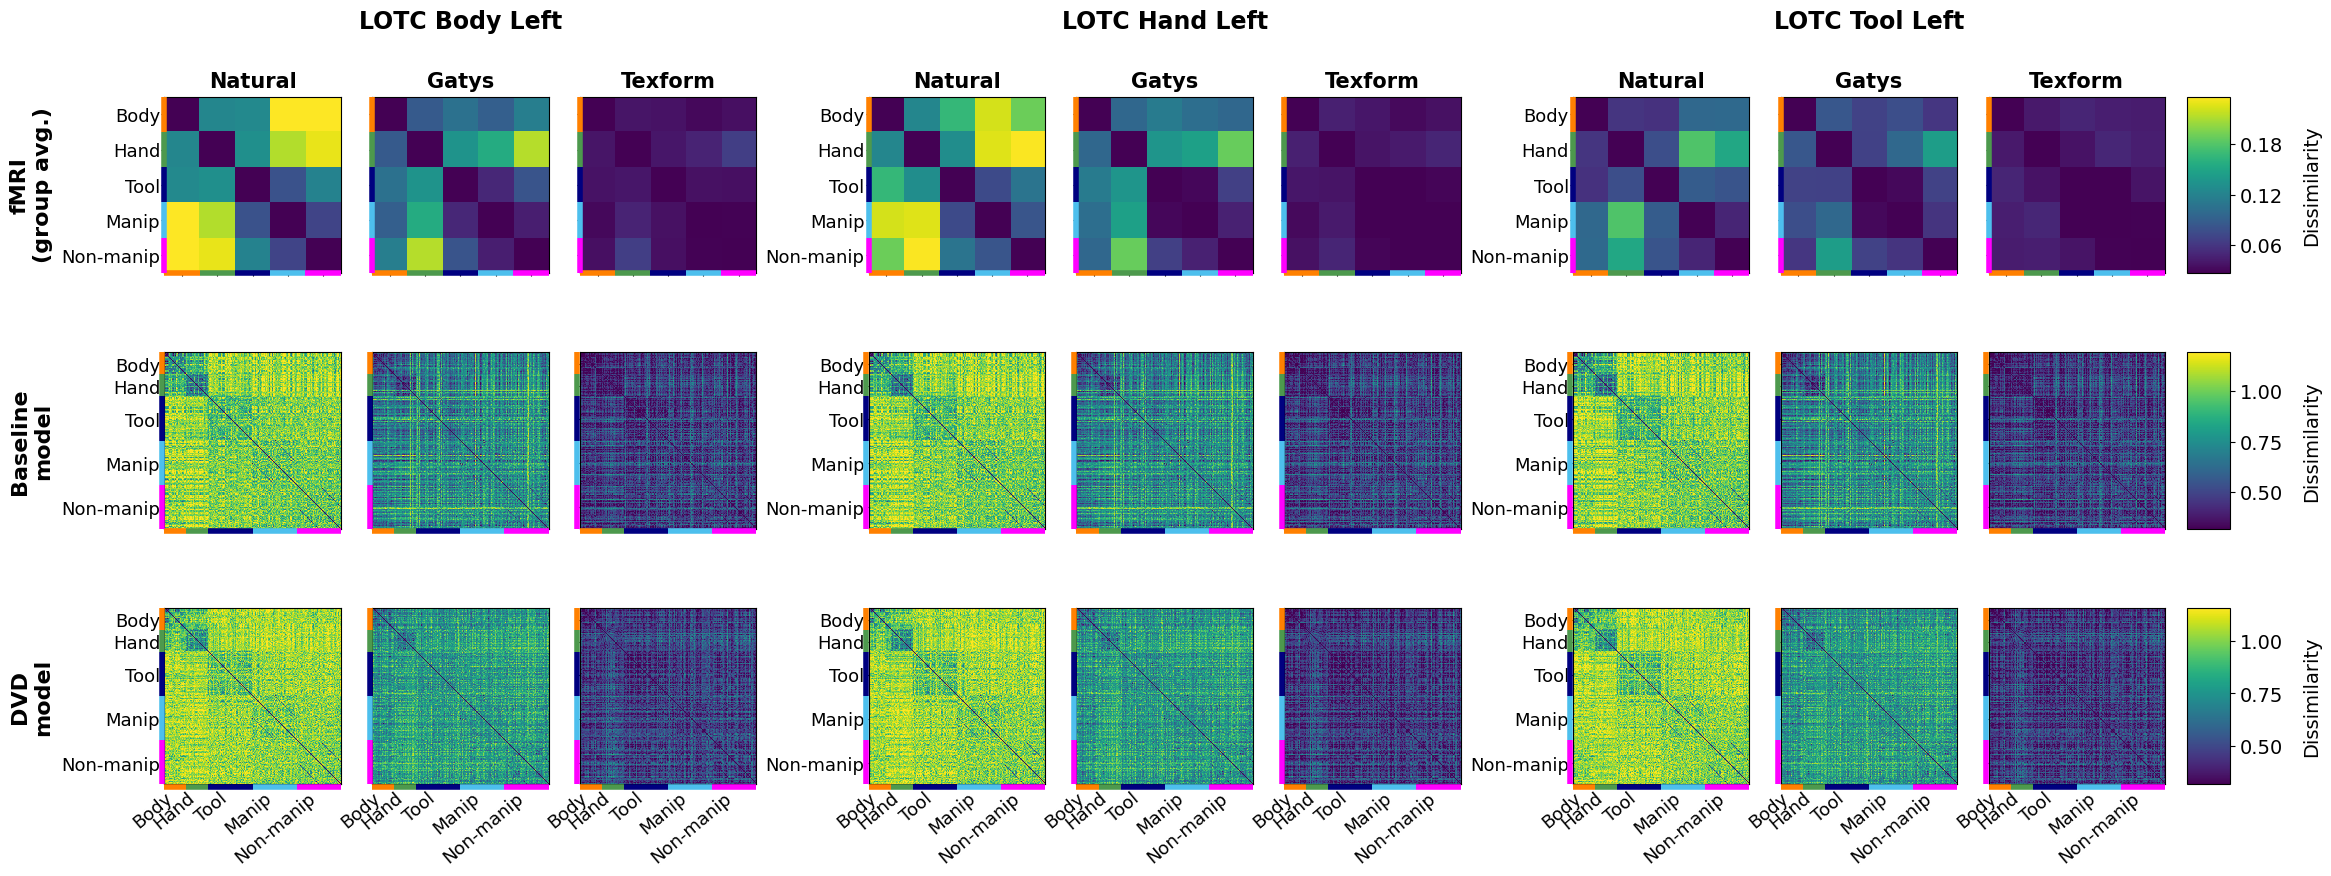

Saved: /Users/lunameidoering/Desktop/CODE/Models/out/rdm_13subs/plots/rdm_overview_3x9_mixed.png


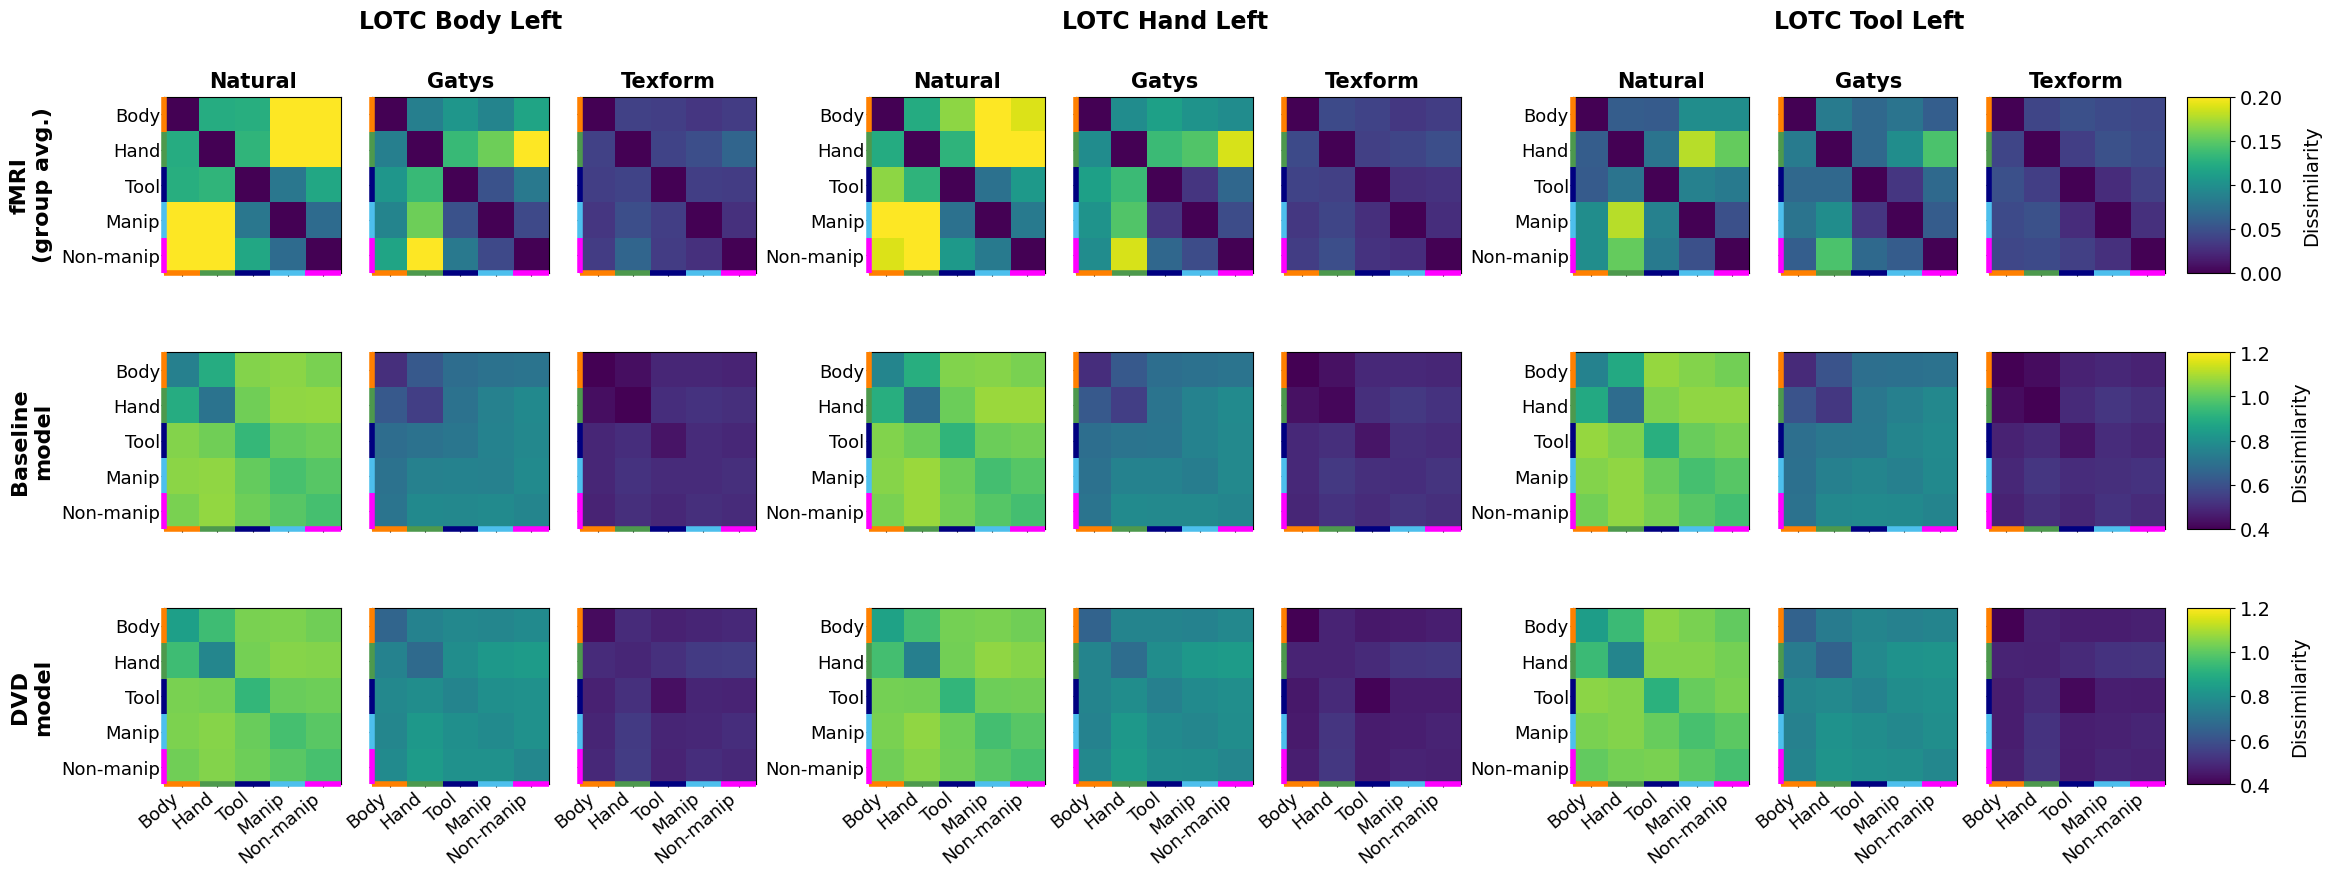

Saved: /Users/lunameidoering/Desktop/CODE/Models/out/rdm_13subs/plots/rdm_overview_3x9_5x5.png


In [ ]:
# RDM GRID

ROI_ORDER_PLOT  = ["body",    "hand",   "tool"]
COND_ORDER_PLOT = ["natural", "gatys",  "texform"]
ROI_TITLE_MAP   = {"body": "LOTC Body Left",
                   "hand": "LOTC Hand Left",
                   "tool": "LOTC Tool Left"}
COND_LABEL_MAP  = {"natural": "Natural", "gatys": "Gatys", "texform": "Texform"}

FS_TICKS      = 13
FS_COND       = 15
FS_TITLE      = 17
FS_ROWLAB     = 16
FS_CBAR       = 14
CBAR_LABELPAD = 14

CAT_COLORS = [
    (1.00, 0.50, 0.00),   # Bodies
    (0.30, 0.60, 0.30),   # Hands
    (0.00, 0.00, 0.50),   # Tools
    (0.30, 0.75, 0.93),   # Manip
    (1.00, 0.00, 1.00),   # Non-manip
]


FMRI_TICK_LABELS_PLOT = [CAT_LABELS[FMRI_TO_IDX_KEY[c]] for c in FMRI_COLS]

VMIN_FMRI  = 0.0;  VMAX_FMRI  = 0.2
VMIN_MODEL = 0.4;  VMAX_MODEL = 1.2

_DATA_W    = 1.0
_SEP_W     = 0.35
_CBAR_W    = 0.22
_gs_widths = []
for _ri in range(3):
    _gs_widths += [_DATA_W, _DATA_W, _DATA_W]
    if _ri < 2:
        _gs_widths.append(_SEP_W)
_gs_widths.append(_CBAR_W)

N_ROWS_PLOT = 3
N_COLS_PLOT = len(ROI_ORDER_PLOT) * len(COND_ORDER_PLOT)  # 9


def _gs_col(logical_col):
    """0-based logical data column (0-8) → GridSpec column index."""
    return logical_col + (logical_col // 3)


fmri_avg_5x5 = {}
for _roi in ROI_ORDER_PLOT:
    for _cond in COND_ORDER_PLOT:
        _mats = [fmri_rdm_dict[(s, _cond, _roi)]
                 for s in SUBJECTS if (s, _cond, _roi) in fmri_rdm_dict]
        if _mats:
            fmri_avg_5x5[(_roi, _cond)] = np.nanmean(_mats, axis=0)


model_avg_5x5 = {}
for _model in ["baseline", "dvdmodel"]:
    for _roi in ROI_ORDER_PLOT:
        for _cond in COND_ORDER_PLOT:
            mat = model_rdm_dict.get((_model, _cond, _roi))
            if mat is None:
                continue
            model_avg_5x5[(_model, _roi, _cond)] = collapse_model_rdm_to_5x5(mat)


def _color_strips_5x5(ax, n):
    """Coloured category strips on left and bottom borders of a 5×5 panel."""
    lw = 4.0
    for i in range(n):
        col   = CAT_COLORS[i % len(CAT_COLORS)]
        start = i / n
        end   = (i + 1) / n
        ax.plot([0, 0], [1 - end, 1 - start],
                transform=ax.transAxes, color=col, linewidth=lw,
                solid_capstyle="butt", clip_on=False, zorder=20)
        ax.plot([start, end], [0, 0],
                transform=ax.transAxes, color=col, linewidth=lw,
                solid_capstyle="butt", clip_on=False, zorder=20)


def _color_strips_200(ax, n_stim):
    """Coloured category strips in data coordinates for 200×200 panels."""
    starts = [0] + [int(b) + 1 for b in cat_boundaries]
    ends   = [int(b) for b in cat_boundaries] + [n_stim - 1]
    off    = -3.5
    lw     = 4.0
    for i, (s, e) in enumerate(zip(starts, ends)):
        col = CAT_COLORS[i % len(CAT_COLORS)]
        ax.plot([off, off], [s - 0.5, e + 0.5],
                color=col, linewidth=lw, solid_capstyle="butt",
                clip_on=False, zorder=10)
        ax.plot([s - 0.5, e + 0.5], [n_stim - 1 - off, n_stim - 1 - off],
                color=col, linewidth=lw, solid_capstyle="butt",
                clip_on=False, zorder=10)


def _draw_5x5(ax, mat, vmin, vmax, xticks=False, yticks=False):
    """Draw a 5×5 RDM heatmap (viridis, coloured category strips)."""
    im = ax.imshow(mat, cmap="viridis", vmin=vmin, vmax=vmax,
                   aspect="equal", interpolation="nearest")
    n = mat.shape[0]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(FMRI_TICK_LABELS_PLOT if xticks else [],
                       rotation=40, ha="right", fontsize=FS_TICKS)
    ax.set_yticklabels(FMRI_TICK_LABELS_PLOT if yticks else [],
                       fontsize=FS_TICKS)
    ax.tick_params(length=2, pad=1)
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    _color_strips_5x5(ax, n)
    return im


def _draw_200(ax, mat, vmin, vmax, xticks=False, yticks=False):
    """Draw a 200×200 RDM heatmap (viridis, category boundary lines, strips)."""
    # FIX 1: Change aspect from "auto" to "equal" to force a square matrix
    im = ax.imshow(mat, cmap="viridis", vmin=vmin, vmax=vmax,
                   aspect="equal", interpolation="nearest")
    n_stim = mat.shape[0]
    
        
    _color_strips_200(ax, n_stim)
    
    ax.set_xticks(cat_centers)
    ax.set_yticks(cat_centers)
    ax.set_xticklabels(FMRI_TICK_LABELS_PLOT if xticks else [],
                       rotation=40, ha="right", fontsize=FS_TICKS)
    ax.set_yticklabels(FMRI_TICK_LABELS_PLOT if yticks else [],
                       fontsize=FS_TICKS)
    ax.tick_params(length=2, pad=1)
    
    # FIX 2: Standardize limits to match data coordinates symmetrically 
    # so the aspect="equal" constraint isn't fighting uneven padding boundaries.
    ax.set_xlim(-0.5, n_stim - 0.5)
    ax.set_ylim(n_stim - 0.5, -0.5)
    
    return im


def build_rdm_figure(row_defs, fig_tag):
    """
    Build and save a 3×9 RDM overview figure.

    row_defs : list of (row_label, getter_fn, draw_fn, vmin, vmax)
    fig_tag  : filename suffix
    """
    fig_w = sum(_gs_widths) * 2.35
    fig_h = N_ROWS_PLOT * 2.6 + 1.25
    fig   = plt.figure(figsize=(fig_w, fig_h))
    gs    = gridspec.GridSpec(
        N_ROWS_PLOT, len(_gs_widths),
        figure=fig,
        width_ratios=_gs_widths,
        wspace=0.08, hspace=0.45,
        left=0.065, right=0.955, top=0.84, bottom=0.08,
    )

    panel_ax  = [[None] * N_COLS_PLOT for _ in range(N_ROWS_PLOT)]
    last_im_r = [None] * N_ROWS_PLOT

    for ri, (row_label, getter, draw_fn, vmin, vmax) in enumerate(row_defs):
        for ci, (roi, cond) in enumerate(
                [(r, c) for r in ROI_ORDER_PLOT for c in COND_ORDER_PLOT]):
            ax = fig.add_subplot(gs[ri, _gs_col(ci)])
            panel_ax[ri][ci] = ax
            mat = getter(roi, cond)
            if mat is None:
                ax.set_visible(False)
                continue
            show_x = (ri == N_ROWS_PLOT - 1)
            show_y = (ci % 3 == 0)
            im = draw_fn(ax, mat, vmin, vmax, xticks=show_x, yticks=show_y)
            last_im_r[ri] = im
            if ri == 0:
                ax.set_title(COND_LABEL_MAP.get(cond, cond),
                             fontsize=FS_COND, fontweight="bold", pad=7)

        cbar_ax = fig.add_subplot(gs[ri, -1])
        if last_im_r[ri] is not None:
            cb = fig.colorbar(last_im_r[ri], cax=cbar_ax)
            cb.ax.tick_params(labelsize=FS_CBAR)
            cb.set_label("Dissimilarity", fontsize=FS_CBAR,
                         labelpad=CBAR_LABELPAD)
            cb.locator = ticker.MaxNLocator(nbins=4)
            cb.update_ticks()

    fig.canvas.draw()

    for ri in range(N_ROWS_PLOT):
        ax0 = panel_ax[ri][0]
        if ax0 is None:
            continue
        bb = ax0.get_position()
        fig.text(0.012, bb.y0 + bb.height / 2,
                 row_defs[ri][0],
                 ha="center", va="center",
                 fontsize=FS_ROWLAB, fontweight="bold",
                 rotation=90, multialignment="center")

    for roi_i, roi in enumerate(ROI_ORDER_PLOT):
        block_axes = [panel_ax[0][roi_i * 3 + ci] for ci in range(3)
                      if panel_ax[0][roi_i * 3 + ci] is not None]
        if not block_axes:
            continue
        x_l = min(ax.get_position().x0 for ax in block_axes)
        x_r = max(ax.get_position().x1 for ax in block_axes)
        y_t = max(ax.get_position().y1 for ax in block_axes)
        fig.text((x_l + x_r) / 2, y_t + 0.07,
                 ROI_TITLE_MAP[roi],
                 ha="center", va="bottom",
                 fontsize=FS_TITLE, fontweight="bold")

    out = plot_output_dir / f"rdm_overview_3x9_{fig_tag}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


# fMRI 5×5 | Baseline 200×200 | DVD 200×200 ──────────────────────
# Colour limits: auto (2nd-98th percentile per row), matching original script.

def _auto_clim(getter_fn):
    vals = []
    for _roi in ROI_ORDER_PLOT:
        for _cond in COND_ORDER_PLOT:
            m = getter_fn(_roi, _cond)
            if m is not None:
                vals.append(upper_tri(m))
    if vals:
        all_v = np.concatenate(vals)
        return float(np.nanpercentile(all_v, 2)), float(np.nanpercentile(all_v, 98))
    return 0.0, 1.0

_getter_fmri     = lambda roi, cond: fmri_avg_5x5.get((roi, cond))
_getter_baseline = lambda roi, cond: model_rdm_dict.get(("baseline", cond, roi))
_getter_dvd      = lambda roi, cond: model_rdm_dict.get(("dvdmodel",  cond, roi))

vmin_fmri_a,     vmax_fmri_a     = _auto_clim(_getter_fmri)
vmin_baseline_a, vmax_baseline_a = _auto_clim(_getter_baseline)
vmin_dvd_a,      vmax_dvd_a      = _auto_clim(_getter_dvd)

row_defs_mixed = [
    ("fMRI\n(group avg.)", _getter_fmri,     _draw_5x5, vmin_fmri_a,     vmax_fmri_a),
    ("Baseline\nmodel",    _getter_baseline,  _draw_200, vmin_baseline_a, vmax_baseline_a),
    ("DVD\nmodel",         _getter_dvd,       _draw_200, vmin_dvd_a,      vmax_dvd_a),
]
build_rdm_figure(row_defs_mixed, "mixed")

# 5x5RDMs
row_defs_5x5 = [
    ("fMRI\n(group avg.)",
     lambda roi, cond: fmri_avg_5x5.get((roi, cond)),
     _draw_5x5, VMIN_FMRI, VMAX_FMRI),
    ("Baseline\nmodel",
     lambda roi, cond: model_avg_5x5.get(("baseline", roi, cond)),
     _draw_5x5, VMIN_MODEL, VMAX_MODEL),
    ("DVD\nmodel",
     lambda roi, cond: model_avg_5x5.get(("dvdmodel", roi, cond)),
     _draw_5x5, VMIN_MODEL, VMAX_MODEL),
]
build_rdm_figure(row_defs_5x5, "5x5")

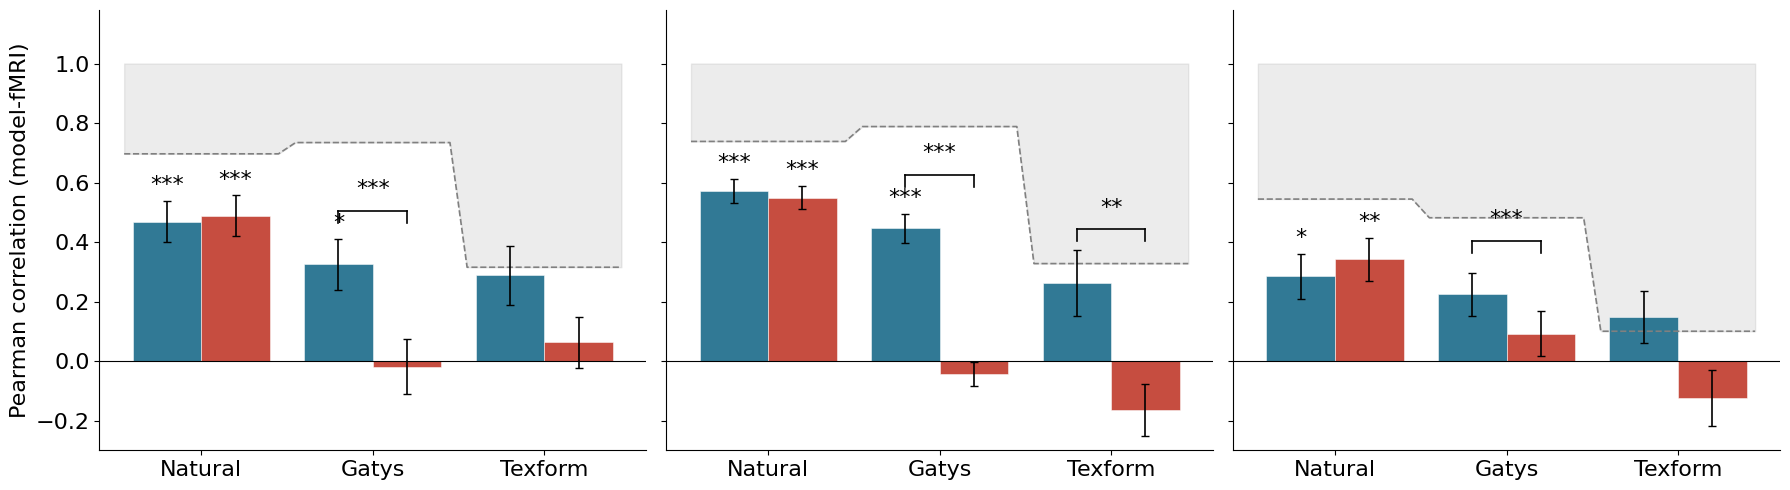

Saved: /Users/lunameidoering/Desktop/CODE/Models/out/rdm_13subs/plots/rsa_barplot_all_rois.png


In [ ]:
# BAR PLOTS with noise ceiling

n_rois, n_conds, n_models = len(ROI_ORDER), len(CONDITION_ORDER), len(MODELS_ORDERED)

fig, axes = plt.subplots(1, n_rois, figsize=(6 * n_rois, 5), sharey=True)
if n_rois == 1:
    axes = [axes]

bar_width = 0.8 / n_models
x         = np.arange(n_conds)

BRACKET_LIFT   = 0.18
BRACKET_HEIGHT = 0.04
STAR_LIFT      = 0.04
BAND_HALF      = 0.45

for ax, roi in zip(axes, ROI_ORDER):

    # Noise ceiling band (lower bound)
    nc_lower = np.array([
        noise_ceiling.get((cond, roi), np.nan) for cond in CONDITION_ORDER
    ])
    x_band  = np.array([xi + s for xi in x for s in (-BAND_HALF, BAND_HALF)])
    nc_band = np.repeat(nc_lower, 2)

    ax.fill_between(x_band, nc_band, np.ones_like(nc_band),
                    alpha=0.15, color="grey", label="Noise ceiling")
    ax.plot(x_band, nc_band, color="grey", linestyle="--", linewidth=1.2)

    
    bar_tops = {}   # model_name → list of (x_centre, bar_height)

    for m_idx, model_name in enumerate(MODELS_ORDERED):
        means, sems = [], []
        for condition in CONDITION_ORDER:
            rhos  = corr_dict.get((model_name, condition, roi), np.array([]))
            valid = rhos[~np.isnan(rhos)]
            means.append(valid.mean() if len(valid) > 0 else np.nan)
            sems.append(valid.std(ddof=1) / np.sqrt(len(valid))
                        if len(valid) > 1 else 0)

        means   = np.array(means)
        sems    = np.array(sems)
        offsets = x + (m_idx - n_models / 2 + 0.5) * bar_width

        bars = ax.bar(offsets, means, width=bar_width,
                      label=MODEL_LABELS[model_name],
                      color=COLORS[model_name], alpha=0.9,
                      edgecolor="white", linewidth=0.4)
        ax.errorbar(offsets, means, yerr=sems,
                    fmt="none", color="black", capsize=3, linewidth=1.2)

        # One-sample significance stars above each bar
        for ci, (condition, bar) in enumerate(zip(CONDITION_ORDER, bars)):
            row = df_onesample[
                (df_onesample.model     == model_name) &
                (df_onesample.condition == condition)  &
                (df_onesample.roi       == roi)
            ]
            if row.empty:
                continue
            star = sig_stars(row["p_corr"].values[0])
            if star not in ("n.s.", "n/a"):
                y_pos = means[ci] + sems[ci] + 0.02
                ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                        star, ha="center", va="bottom",
                        fontsize=16, color="black")

        bar_tops[model_name] = list(zip(
            offsets, np.where(np.isnan(means), 0, means)
        ))

    # ── Paired t-test brackets (dvd vs baseline) ─────────────────────────────
    for ci, condition in enumerate(CONDITION_ORDER):
        row = df_paired[
            (df_paired.condition == condition) &
            (df_paired.roi       == roi)
        ]
        if row.empty:
            continue

        star  = sig_stars(row["p_corr"].values[0])
        color = "black" if star not in ("n.s.", "n/a") else "none"
        alpha = 1.0     if star not in ("n.s.", "n/a") else 0

        x_l, y_l = bar_tops["baseline"][ci]
        x_r, y_r = bar_tops["dvdmodel"][ci]
        y_brack  = max(y_l, y_r) + BRACKET_LIFT

        ax.plot([x_l, x_r], [y_brack, y_brack],
                color=color, linewidth=1.2, alpha=alpha)
        ax.plot([x_l, x_l], [y_brack - BRACKET_HEIGHT, y_brack],
                color=color, linewidth=1.2, alpha=alpha)
        ax.plot([x_r, x_r], [y_brack - BRACKET_HEIGHT, y_brack],
                color=color, linewidth=1.2, alpha=alpha)
        ax.text((x_l + x_r) / 2, y_brack + STAR_LIFT, star,
                ha="center", va="bottom",
                fontsize=16, color=color, alpha=alpha)

    # ── Axes styling ──────────────────────────────────────────────────────────
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in CONDITION_ORDER], fontsize=16)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_ylim(top=1.18, bottom=-0.3)


axes[0].set_ylabel("Pearman correlation (model-fMRI)", fontsize=16)

handles = [
    mpatches.Patch(color=COLORS[m], alpha=0.9, label=MODEL_LABELS[m])
    for m in MODELS_ORDERED
]
handles.append(
    mpatches.Patch(facecolor="grey", alpha=0.15, label="Noise ceiling")
)

plt.tight_layout()
out = plot_output_dir / "rsa_barplot_all_rois.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

In [ ]:
# df_long for line plots

long_rows = []
for (model_name, condition, roi), rhos in corr_dict.items():
    for sub, rho in zip(SUBJECTS, rhos):
        if not np.isnan(rho):
            long_rows.append({"subject": sub, "model": model_name,
                              "condition": condition, "roi": roi, "rho": rho})
df_long = pd.DataFrame(long_rows)
print(f"df_long: {len(df_long)} rows")


df_long: 228 rows
